# **Algorithm : Support Vector Regression(SVR)**
## **Project : Stock Price Forecasting**

In [2]:
# Step No 1 : Import Required Libraries 

# Import Numerical Library
import numpy as np 

# Import Pandas Library 
import pandas as pd 

# Import Plotting Library 
import matplotlib.pyplot as plt 

# Import Seaborn Library 
import seaborn as sns 

# Import Standard Scaler
from sklearn.preprocessing import StandardScaler

# Import Support Vector Regression 
from sklearn.svm import SVR

# Import Evaluation Metrics
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
# Step No 2 : Load Dataset 
# Load Stock Dataset 
df = pd.read_csv("Stock_Price_Forecasting_Dataset.csv")

In [4]:
# Step No 3 : Data Understanding 
# Display first 5 rows 
print("First 5 Rows : ")
print(df.head())

# Display dataset shape 
print("\nDataset Shape : ")
print(df.shape)

# Display column names 
print("\nColumn Names : ")
print(df.columns.tolist())

# Display dataset information 
print("\nDataset Information : ")
print(df.info())

# Display Statistical Summary 
print("\nStatistical Summary : ")
print(df.describe())

First 5 Rows : 
         Date    Open    High     Low   Close  Volume
0  2022-01-03  100.34  100.94   99.88  100.00  190183
1  2022-01-04  101.79  102.34   99.40  100.94  153986
2  2022-01-05  101.30  101.42  100.05  100.74  375897
3  2022-01-06  102.00  102.65  101.63  101.97  163783
4  2022-01-07  104.41  105.07  102.83  104.81  261655

Dataset Shape : 
(1000, 6)

Column Names : 
['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

Dataset Information : 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1000 non-null   object 
 1   Open    1000 non-null   float64
 2   High    1000 non-null   float64
 3   Low     1000 non-null   float64
 4   Close   1000 non-null   float64
 5   Volume  1000 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 47.0+ KB
None

Statistical Summary : 
              Open         High          Low   

In [5]:
# Step No 4 : Data Cleaning 
# Check Missing Values 
print("\nMissing Values : ")
print(df.isnull().sum())

# Check duplicate rows 
print("\nDuplicate Rows : ")
print(df.duplicated().sum())

# Remove Duplicate rows 
df = df.drop_duplicates()


Missing Values : 
Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

Duplicate Rows : 
0


In [6]:
# Step No 5 : Convert Date Column 
# Convert Date Column into datetime format 
df["Date"] = pd.to_datetime(df["Date"])

# Sort dataset accroding to date 
df = df.sort_values(by="Date")

# Reset index 
df = df.reset_index(drop=True)

In [7]:
# Step No 6 : Create Features
# Define input features 
X = df[
    [
        "Open",
        "High",
        "Low",
        "Volume"
    ]
]

# Define target variable
y = df["Close"]

# Display feature shape 
print("\nFeature Shape : ")
print(X.shape)

# Display target shape 
print("\nTarget Shape : ")
print(y.shape)


Feature Shape : 
(1000, 4)

Target Shape : 
(1000,)


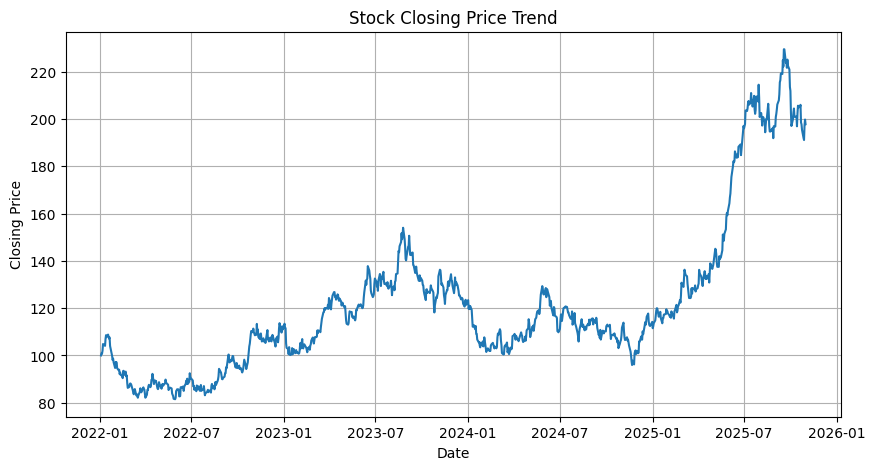

In [8]:
# Step No 7 : Stock Price Visualization

# Create figure 
plt.figure(figsize=(10 , 5))

# Plot Date Vs Close Price 
plt.plot(
    df["Date"],
    df["Close"]
)

# Set title 
plt.title("Stock Closing Price Trend")

# Set x-axis label  
plt.xlabel("Date")

# Set y-axis label 
plt.ylabel("Closing Price")

# Enable grid 
plt.grid()

# Display plot 
plt.show()

In [9]:
# Step No 8 : Train - Test Split 
# Calculate Training Size 
train_size = int(
    len(df) * 0.80
)

# Create training features 
X_train = X.iloc[:train_size]

# Create testing features 
X_test = X.iloc[
    train_size:
]

# Create training target 
y_train = y.iloc[
    :train_size
]

# Create testing target 
y_test = y.iloc[
    train_size:
]

# Display training size 
print("\nTraining Samples : ")
print(len(X_train))

# Display testing size 
print("\nTesting Samples : ")
print(len(X_test))


Training Samples : 
800

Testing Samples : 
200


In [10]:
# Step No 9 : Feature Scaling 

# Create feature scaler 
feature_scaler = StandardScaler()

# Fit and transform training features 
X_train_scaled = feature_scaler.fit_transform(
    X_train
)

# Transform testing features 
X_test_scaled = feature_scaler.transform(X_test)

# Create target scaler 
target_scaler = StandardScaler()

# Convert target into 2D array 
y_train_array = y_train.values.reshape(
    -1 , 
    1
)

# Scale training target 
y_train_scaled = target_scaler.fit_transform(
    y_train_array
).ravel()

In [11]:
# Step No 10 : Create SVR Model 
# Create Support Vector Regression Model 
model = SVR(
    kernel="rbf",
    C = 100,
    gamma="scale",
    epsilon= 0.1
)

# Display model 
print("\nSVR Model : ")
print(model)


SVR Model : 
SVR(C=100)


In [12]:
# Step No 11 : Train SVR Model 
# Train SVR Model 
model.fit(
    X_train_scaled,
    y_train_scaled
)

# Display training message 
print("\nSVR Model Training Completed.")


SVR Model Training Completed.


In [13]:
# Step No 12 : Prediction 
# Predict Scaled Closing prices 
y_pred_scaled = model.predict(
    X_test_scaled
)

# Convert predictions back 
# into original price scale 
y_pred = target_scaler.inverse_transform(
    y_pred_scaled.reshape(
        -1 , 
        1
    )
).ravel()

# Display predicted values 
print("\nPredicted Closing Prices : ")
print(y_pred)


Predicted Closing Prices : 
[117.3725069  119.8915954  118.91955096 118.2897697  117.39241197
 115.83295635 115.9186975  116.99580095 115.72226302 118.08398311
 117.18805399 115.79507255 115.63576687 119.83533989 119.49549497
 121.68660618 117.58548654 117.9932915  120.84069023 120.99274124
 123.2260178  122.43312724 125.72000459 130.13575779 129.68632959
 128.43435625 132.11150424 135.56282342 134.55310096 133.34964088
 132.71703969 130.87521278 128.28538773 126.73773725 124.25875579
 123.16071273 124.41243034 128.15077958 126.60563482 128.76333031
 127.59545003 127.89279738 128.65715936 126.74146946 128.0348613
 127.69804763 128.31064811 130.31424478 134.71218644 134.69820343
 132.62561417 131.37282069 131.32112407 128.03954065 131.73096789
 136.259892   133.26009921 131.91024209 132.64044389 131.98092347
 133.18888023 133.84410472 130.40916034 134.85664451 137.15155415
 137.84957451 134.56507977 138.65778524 138.72032274 138.87639544
 145.04852024 144.20024185 142.32079612 138.4560

In [15]:
# Step No 13 : Model Evaluation 
# Calculate Mean Absolute Error 
mae = mean_absolute_error(
    y_test , 
    y_pred
)

# Calculate Mean Squared Error 
mse = mean_squared_error(
    y_test , 
    y_pred
)

# Calculate Root Mean Squared Error 
rmse = np.sqrt(mse)

# Calculate R2 Score 
r2 = r2_score(
    y_test , 
    y_pred
)

# Display MAE 
print("\nMean Absolute Error : ")
print(mae)

# Display MSE 
print("\nMean Squared Error : ")
print(mse)

# Display RMSE 
print("\nRoot Mean Squared Error : ")
print(rmse)

# Display R2 Score 
print("\nR2 Score : ")
print(r2)


Mean Absolute Error : 
46.39469630878473

Mean Squared Error : 
3950.7855609992425

Root Mean Squared Error : 
62.85527472694112

R2 Score : 
-2.005078598110802


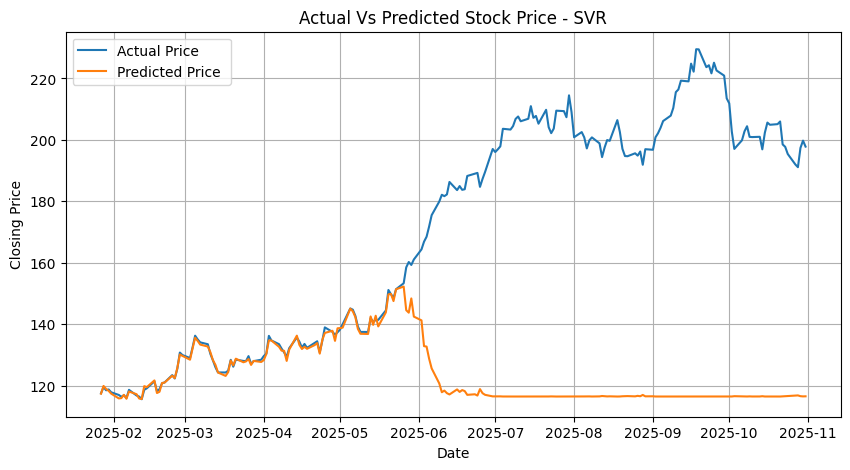

In [16]:
# Step No 14 : Actual Vs Predicted Visualization 
# Create figure 
plt.figure(
    figsize=(10 , 5)
)

# Plot Actual Closing Prices
plt.plot(
    df["Date"].iloc[train_size:],
    y_test.values,
    label = "Actual Price "
)

# Plot Predicted Closing Prices 
plt.plot(
    df["Date"].iloc[train_size:],
    y_pred,
    label = "Predicted Price "
)

# Set title 
plt.title("Actual Vs Predicted Stock Price - SVR")

# Set x-axis label 
plt.xlabel("Date")

# Set y-axis label 
plt.ylabel("Closing Price")

# Display legend 
plt.legend()

# Enable grid 
plt.grid()

# Display Plot 
plt.show()

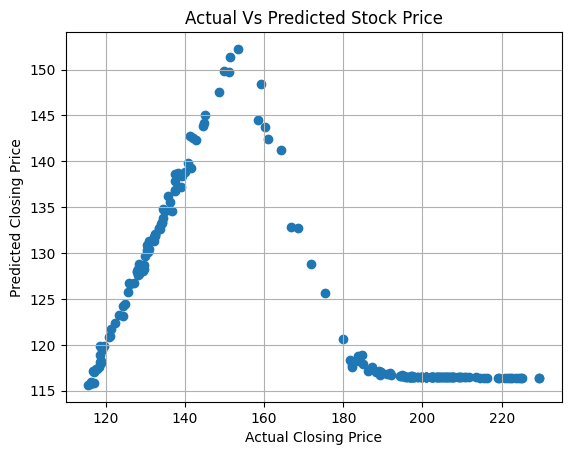

In [17]:
# Step No 15 : Actual Vs Predicted Scatter Plot 

# Create Scatter Plot 
plt.scatter(
    y_test , 
    y_pred
)

# Set title 
plt.title("Actual Vs Predicted Stock Price")

# Set x-axis label 
plt.xlabel("Actual Closing Price")

# Set y-axis label 
plt.ylabel("Predicted Closing Price")

# Enable Grid 
plt.grid()

# Display Plot 
plt.show()

In [18]:
# Step No 16 : User Input 
# Take Open Price Input
open_price = float(
    input(
        "\nEnter Open Price : "
    )
)

# Take High Price Input 
high_price = float(
    input(
        "Enter High Price : "
    )
)

# Take Low Price Input
low_price = float(
    input(
        "Enter Low Price : "
    )
)

# Take Volume Input 
volume = float(
    input(
        "Enter Trading Volume : "
    )
) 

In [20]:
# Step No 17 : Create User Dataframe 
# Create dataframe for user input 
user_data = pd.DataFrame({
    "Open": [open_price],
    "High": [high_price],
    "Low": [low_price],
    "Volume":[volume]
})

In [21]:
# Step No 18 : Scale User Data 
# Scale User Input Using 
# Previously fitted feature scaler 
user_data_scaled = feature_scaler.transform(
    user_data
)

In [22]:
# Step No 19 : Predict Stock Price 
# Predict Scaled Stock Price 
user_prediction_scaled = model.predict(
    user_data_scaled
)

# Convert prediction back 
# into original price scale 
user_prediction = target_scaler.inverse_transform(
    user_prediction_scaled.reshape(
        -1,
        1
    )
).ravel()

In [23]:
# Step No 20 : Final Output 
# Display Predicted Stock Price 
print(
    "\nPredicted Stock Closing Price : ₹",
    round(
        user_prediction[0],
        2
    )
)


Predicted Stock Closing Price : ₹ 116.44
